# Section 2.4 - Tariffs are Lower on AI-Related Products
Generates: figures/ai-tariffs.pdf/png.
**Run after 06** - appends to tables/ai-trade-results.tex.


In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [2]:
# Define paths for output files
texfile = "paper/tables/ai-trade-results.tex"
figfile = "paper/figures/"

In [3]:
matlist = pd.read_csv('data-input/hs10_classification_final_v3.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [4]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [5]:
df = pd.read_parquet('data-input/TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [6]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2726615,TOTAL FOR ALL COUNTRIES,1031361,308288,1605514000,"OYSTERS, SMOKED",2026-01-01,HS10,16,1605,1031361.0,308288.0
2726616,TOTAL FOR ALL COUNTRIES,582408,92228,1605515000,"OYSTERS EXCEPT SMOKED, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,582408.0,92228.0
2726617,TOTAL FOR ALL COUNTRIES,310800,36176,1605520500,SCALLOP PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,310800.0,36176.0
2726618,TOTAL FOR ALL COUNTRIES,412467,91158,1605526000,"SCALLOPS, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,412467.0,91158.0
2726619,TOTAL FOR ALL COUNTRIES,368316,37195,1605530500,MUSSEL PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,368316.0,37195.0


In [7]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [8]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty,relevance,primary_category,reasoning
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,0602,773010.0,0.0,Low,Not_DC_Related,Roses are ornamental plants used for landscapi...
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,0602,6177543.0,0.0,Low,Not_DC_Related,Live orchid plants are ornamental/decorative p...
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,0602,135786.0,0.0,Low,Not_DC_Related,These are live flowering plants (chrysanthemum...
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,0602,169439.0,0.0,Low,Not_DC_Related,This product is live herbaceous perennial plan...
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,0602,2177498.0,25345.0,Low,Not_DC_Related,Live herbaceous perennial plants from nurserie...


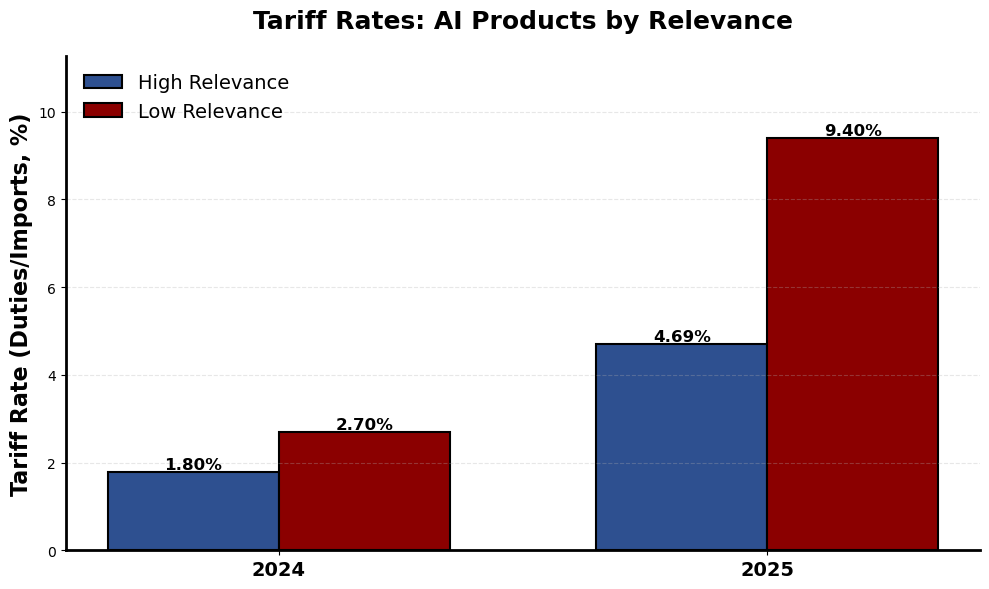


Tariff Rates (Duties/Imports):
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  2025:
    High Relevance: 4.69%
    Low Relevance:  9.40%


In [9]:
# Calculate tariff rates (duty/imports) for High vs Low relevance products
# for 2024 and 2025

df_reset = df.reset_index()

years = [2024, 2025]
tariff_data = {'High': [], 'Low': []}

for year in years:
    year_str = str(year)
    year_data = df_reset[df_reset['time'].dt.year == year]
    
    for rel in ['High', 'Low']:
        rel_data = year_data[year_data['relevance'] == rel]
        total_duty = rel_data['duty'].sum()
        total_imports = rel_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        tariff_data[rel].append(tariff_rate)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(years))
width = 0.35

bars1 = ax.bar(x - width/2, tariff_data['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, tariff_data['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
ax.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=16, fontweight='bold')
ax.set_title('Tariff Rates: AI Products by Relevance', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylim(0, max(max(tariff_data['High']), max(tariff_data['Low'])) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(fontsize=14, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()



print(f"\nTariff Rates (Duties/Imports):")
for i, year in enumerate(years):
    print(f"  {year}:")
    print(f"    High Relevance: {tariff_data['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data['Low'][i]:.2f}%")

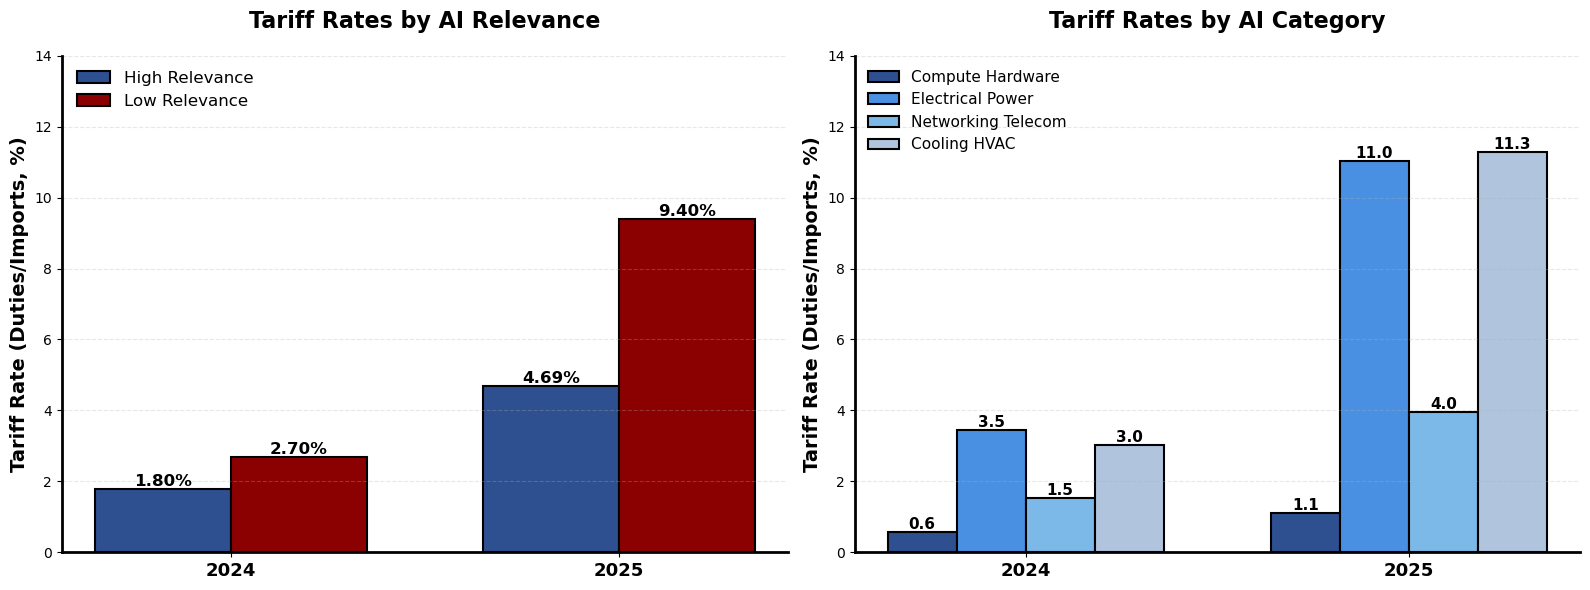


Tariff Rates Summary:

By Relevance:
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  2025:
    High Relevance: 4.69%
    Low Relevance:  9.40%

By Category (High Relevance only):
  Compute Hardware:
    2024: 0.56%
    2025: 1.11%
  Electrical Power:
    2024: 3.46%
    2025: 11.04%
  Networking Telecom:
    2024: 1.54%
    2025: 3.96%
  Cooling HVAC:
    2024: 3.04%
    2025: 11.28%


In [10]:
# Two-panel figure: Tariff rates by category (left) and by relevance (right)

years = [2024, 2025]
df_reset = df.reset_index()

# Calculate tariff rates for relevance comparison (High vs Low)
tariff_data_relevance = {'High': [], 'Low': []}
for year in years:
    year_data = df_reset[df_reset['time'].dt.year == year]
    
    for rel in ['High', 'Low']:
        rel_data = year_data[year_data['relevance'] == rel]
        total_duty = rel_data['duty'].sum()
        total_imports = rel_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        tariff_data_relevance[rel].append(tariff_rate)

# Calculate tariff rates for category breakdown (only top 4 categories)
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()
top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

category_tariffs_subset = {}
for cat in top_4_cats:
    category_tariffs_subset[cat] = []
    for year in years:
        year_data = df_high_only[(df_high_only['time'].dt.year == year) & 
                                  (df_high_only['primary_category'] == cat)]
        total_duty = year_data['duty'].sum()
        total_imports = year_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        category_tariffs_subset[cat].append(tariff_rate)

# Create two-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PANEL: Tariff rates by relevance (High vs Low)
x = np.arange(len(years))
width = 0.35

bars1 = ax1.bar(x - width/2, tariff_data_relevance['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, tariff_data_relevance['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting left panel
ax1.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax1.set_title('Tariff Rates by AI Relevance', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.set_ylim(0, 14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', labelsize=13)
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["left"].set_linewidth(2)
ax1.spines["bottom"].set_linewidth(2)
ax1.legend(fontsize=12, frameon=False, loc='upper left')

# RIGHT PANEL: Tariff rates by category (4 categories only)
x = np.arange(len(years))
width = 0.18
n_cats = len(category_tariffs_subset)
offset = np.arange(n_cats) - (n_cats - 1) / 2

colors_cat = ['#2E5090', '#4A90E2', '#7CB9E8', '#B0C4DE']

for i, (cat, tariffs) in enumerate(category_tariffs_subset.items()):
    label = cat.replace('_', ' ')
    bars = ax2.bar(x + offset[i] * width, tariffs, width, 
                   label=label, color=colors_cat[i], 
                   edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting right panel
ax2.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax2.set_title('Tariff Rates by AI Category', fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_ylim(0, 14)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelsize=13)
for label in ax2.get_xticklabels():
    label.set_fontweight('bold')
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_linewidth(2)
ax2.spines["bottom"].set_linewidth(2)
ax2.legend(fontsize=11, frameon=False, loc='upper left', ncol=1)

plt.savefig(figfile+"ai-tariffs.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-tariffs.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()



print(f"\nTariff Rates Summary:")
print(f"\nBy Relevance:")
for i, year in enumerate(years):
    print(f"  {year}:")
    print(f"    High Relevance: {tariff_data_relevance['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data_relevance['Low'][i]:.2f}%")

print(f"\nBy Category (High Relevance only):")
for cat, tariffs in category_tariffs_subset.items():
    print(f"  {cat.replace('_', ' ')}:")
    for i, year in enumerate(years):
        print(f"    {year}: {tariffs[i]:.2f}%")

In [11]:
# Write tariff rate values to LaTeX file
with open(texfile, 'a') as f:
    # Tariff rates by relevance
    f.write(f'\\def\\tariffHighTwentyFour{{{tariff_data_relevance["High"][0]:.1f}}} % High AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\def\\tariffHighTwentyFive{{{tariff_data_relevance["High"][1]:.1f}}} % High AI relevance tariff rate in 2025 (%)\n')
    f.write(f'\\def\\tariffLowTwentyFour{{{tariff_data_relevance["Low"][0]:.1f}}} % Low AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\def\\tariffLowTwentyFive{{{tariff_data_relevance["Low"][1]:.1f}}} % Low AI relevance tariff rate in 2025 (%)\n')
    
    # Tariff rates by category
    for cat in top_4_cats:
        cat_clean = cat.replace('_', '')
        cat_name = cat.replace('_', ' ')
        tariffs = category_tariffs_subset[cat]
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFour}}{{{tariffs[0]:.1f}}} % {cat_name} tariff rate in 2024 (%)\n')
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFive}}{{{tariffs[1]:.1f}}} % {cat_name} tariff rate in 2025 (%)\n')

print(f"\nAppended tariff rate values to {texfile}")
print(f"\nBy Relevance:")
print(f"  High: {tariff_data_relevance['High'][0]:.1f}% (2024), {tariff_data_relevance['High'][1]:.1f}% (2025)")
print(f"  Low: {tariff_data_relevance['Low'][0]:.1f}% (2024), {tariff_data_relevance['Low'][1]:.1f}% (2025)")
print(f"\nBy Category:")
for cat in top_4_cats:
    tariffs = category_tariffs_subset[cat]
    print(f"  {cat.replace('_', ' ')}: {tariffs[0]:.1f}% (2024), {tariffs[1]:.1f}% (2025)")


Appended tariff rate values to paper/tables/ai-trade-results.tex

By Relevance:
  High: 1.8% (2024), 4.7% (2025)
  Low: 2.7% (2024), 9.4% (2025)

By Category:
  Compute Hardware: 0.6% (2024), 1.1% (2025)
  Electrical Power: 3.5% (2024), 11.0% (2025)
  Networking Telecom: 1.5% (2024), 4.0% (2025)
  Cooling HVAC: 3.0% (2024), 11.3% (2025)
